# Queue System Analysis: Disney World Monorail
## Continuous-Time Markov Chain (CTMC) — M/M/c Model

**Author:** Ilham Khadafi  
**Dataset:** Disney World Ride Wait Times (publicly available)

---

### Problem Statement

This project models the **Disney World Monorail** boarding queue as a **continuous-time Markov chain (CTMC)** under the **M/M/c** framework. The goals are:

1. Estimate arrival rate (λ) and service rate (μ) from empirical data using **Maximum Likelihood Estimation (MLE)**
2. Construct the **generator matrix Q** of the underlying birth-death process
3. Derive **steady-state performance metrics** (Erlang-C, utilization, average queue length, waiting time)
4. Validate model predictions against observed wait times
5. Provide **capacity planning recommendations** through sensitivity analysis on the number of servers (c)

### M/M/c Assumptions

- Inter-arrival times are **i.i.d. Exponential(λ)** — Poisson arrival process
- Service times are **i.i.d. Exponential(μ)** per server — memoryless service
- There are **c parallel servers** (monorail units/trains), infinite queue capacity, FCFS discipline
- The system is analyzed in **steady state**, requiring ρ = λ/(cμ) < 1

## 1. Environment Setup

In [4]:
# Standard library
import math
import warnings
warnings.filterwarnings("ignore")

# Data & numerics
import numpy as np
import pandas as pd
from scipy import stats

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Display settings
pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Model configuration
WAHANA   = "Monorail"
N_STATES = 15
Q_SIZE   = 6

print("Libraries loaded.")

Libraries loaded.


## 2. Data Loading & Initial Inspection

In [7]:
df = pd.read_csv("waiting_times.csv")

print(f"Shape          : {df.shape}")
print(f"Columns        : {df.columns.tolist()}")
print(f"Date range     : {df['WORK_DATE'].min()} — {df['WORK_DATE'].max()}")
print(f"Unique rides   : {df['ENTITY_DESCRIPTION_SHORT'].nunique()}")
print(df.head())
print(df.dtypes)

Shape          : (1739854, 14)
Columns        : ['WORK_DATE', 'DEB_TIME', 'DEB_TIME_HOUR', 'FIN_TIME', 'ENTITY_DESCRIPTION_SHORT', 'WAIT_TIME_MAX', 'NB_UNITS', 'GUEST_CARRIED', 'CAPACITY', 'ADJUST_CAPACITY', 'OPEN_TIME', 'UP_TIME', 'DOWNTIME', 'NB_MAX_UNIT']
Date range     : 2018-01-01 — 2020-04-20
Unique rides   : 37
    WORK_DATE                 DEB_TIME  DEB_TIME_HOUR  \
0  2018-01-01  2018-01-01 21:00:00.000             21   
1  2018-01-01  2018-01-01 19:30:00.000             19   
2  2018-01-01  2018-01-01 22:30:00.000             22   
3  2018-01-01  2018-01-01 12:45:00.000             12   
4  2018-01-01  2018-01-01 17:00:00.000             17   

                  FIN_TIME ENTITY_DESCRIPTION_SHORT  WAIT_TIME_MAX  NB_UNITS  \
0  2018-01-01 21:15:00.000           Roller Coaster              0    2.0000   
1  2018-01-01 19:45:00.000              Bumper Cars              5   18.0000   
2  2018-01-01 22:45:00.000              Rapids Ride              0    1.0000   
3  2018-01-01 13:

## 3. Data Preprocessing

In [ ]:
# Parse datetime columns
df["WORK_DATE"] = pd.to_datetime(df["WORK_DATE"])
df["DEB_TIME"]  = pd.to_datetime(df["DEB_TIME"])
df["FIN_TIME"]  = pd.to_datetime(df["FIN_TIME"])

# Filter to Monorail only
mono = df[df["ENTITY_DESCRIPTION_SHORT"] == WAHANA].copy()
mono = mono.sort_values("DEB_TIME").reset_index(drop=True)

# Compute interval duration in minutes
mono["interval_min"] = (mono["FIN_TIME"] - mono["DEB_TIME"]).dt.total_seconds() / 60

# Drop rows with non-positive interval or zero guests carried
mono = mono[(mono["interval_min"] > 0) & (mono["GUEST_CARRIED"] > 0)].reset_index(drop=True)

# Determine number of servers (c) as the mode of NB_UNITS
c_mode = int(mono["NB_UNITS"].mode()[0])

print(f"Ride filtered  : {WAHANA}")
print(f"Records        : {len(mono):,}")
print(f"Date range     : {mono['WORK_DATE'].min().date()} — {mono['WORK_DATE'].max().date()}")
print(f"NB_UNITS stats :")
print(mono["NB_UNITS"].value_counts().sort_index())
print(f"\nc (mode of NB_UNITS) : {c_mode}")
print()
print(mono[["WORK_DATE", "DEB_TIME", "FIN_TIME", "interval_min",
            "GUEST_CARRIED", "NB_UNITS", "WAIT_TIME_MAX"]].head(10))# Parse datetime columns

Ride filtered  : Monorail
Records        : 30,108
Date range     : 2018-01-01 — 2020-03-13
NB_UNITS stats :
NB_UNITS
0.0000      1
4.8000      1
5.0000      2
6.0000      5
6.2667      1
           ..
12.7333     1
13.0000     1
13.8667     1
13.9333     1
14.0000    12
Name: count, Length: 78, dtype: int64

c (mode of NB_UNITS) : 11

   WORK_DATE            DEB_TIME            FIN_TIME  interval_min  \
0 2018-01-01 2018-01-01 09:00:00 2018-01-01 09:15:00       15.0000   
1 2018-01-01 2018-01-01 09:15:00 2018-01-01 09:30:00       15.0000   
2 2018-01-01 2018-01-01 09:30:00 2018-01-01 09:45:00       15.0000   
3 2018-01-01 2018-01-01 09:45:00 2018-01-01 10:00:00       15.0000   
4 2018-01-01 2018-01-01 10:00:00 2018-01-01 10:15:00       15.0000   
5 2018-01-01 2018-01-01 10:15:00 2018-01-01 10:30:00       15.0000   
6 2018-01-01 2018-01-01 10:30:00 2018-01-01 10:45:00       15.0000   
7 2018-01-01 2018-01-01 10:45:00 2018-01-01 11:00:00       15.0000   
8 2018-01-01 2018-01-01 11:00:00 

## 4. Parameter Estimation (MLE)

Since the dataset contains **aggregated 15-minute interval records** rather than individual arrival event logs, λ and μ are estimated directly from interval-level counts:

- **λ (arrival rate):** guests carried per interval ÷ interval duration → averaged across all intervals
- **μ (service rate per server):** λ ÷ (c × ρ_est), where ρ_est is the per-interval utilization estimated from `UP_TIME / OPEN_TIME`
- **c (number of servers):** mode of `NB_UNITS` across all intervals

Inter-arrival times cannot be directly observed from this data. To validate the Poisson arrival assumption, we instead test whether **interval guest counts follow a Poisson distribution** using a chi-squared goodness-of-fit test.

In [9]:
# Arrival rate per interval: guests carried / interval duration
mono["lambda_est"] = mono["GUEST_CARRIED"] / mono["interval_min"]

# Utilization per interval from uptime ratio (clip to valid range)
mono["rho_est"] = (mono["UP_TIME"] / mono["OPEN_TIME"]).clip(0.01, 0.99)

# Service rate per server derived from Little's Law inversion:
# rho = lambda / (c * mu)  =>  mu = lambda / (c * rho)
mono["c_interval"] = mono["NB_UNITS"].round().clip(lower=1)
mono["mu_est"] = mono["lambda_est"] / (mono["c_interval"] * mono["rho_est"])

# Drop rows where mu_est is non-finite
mono = mono[np.isfinite(mono["mu_est"]) & (mono["mu_est"] > 0)].reset_index(drop=True)

# Global parameter estimates
lambda_hat = mono["lambda_est"].mean()
mu_hat     = mono["mu_est"].mean()
c          = c_mode
r          = lambda_hat / mu_hat
rho        = lambda_hat / (c * mu_hat)

print("PARAMETER ESTIMATES (MLE)")
print(f"lambda_hat  (arrival rate)        : {lambda_hat:.4f} guests/min")
print(f"mu_hat      (service rate/server) : {mu_hat:.4f} guests/min/server")
print(f"c           (number of servers)   : {c}")
print(f"r = lambda/mu (offered load)      : {r:.4f}")
print(f"rho = lambda/(c*mu)               : {rho:.4f}  ({rho*100:.2f}%)")
print(f"System stable (rho < 1)           : {rho < 1}")

PARAMETER ESTIMATES (MLE)
lambda_hat  (arrival rate)        : 9.1056 guests/min
mu_hat      (service rate/server) : 0.8602 guests/min/server
c           (number of servers)   : 11
r = lambda/mu (offered load)      : 10.5850
rho = lambda/(c*mu)               : 0.9623  (96.23%)
System stable (rho < 1)           : True


## 5. Goodness-of-Fit Test

To validate the **Poisson arrival assumption**, we test whether the number of guests carried per 15-minute interval follows a Poisson distribution. A chi-squared goodness-of-fit test is used, grouping tail bins to ensure expected frequencies ≥ 5.

> **Note on sample size sensitivity:** With n = 30,000+ observations, even negligible deviations from the theoretical distribution can produce statistically significant results. The test p-value should therefore be interpreted alongside the effect size (standardized residuals) rather than used as a binary pass/fail criterion.

In [10]:
counts = mono["GUEST_CARRIED"].astype(int)
lambda_poisson = counts.mean()

# Observed frequency table
obs_counts = counts.value_counts().sort_index()
min_val, max_val = obs_counts.index.min(), obs_counts.index.max()

# Expected frequencies under Poisson(lambda_poisson)
all_vals = np.arange(min_val, max_val + 1)
expected_probs = stats.poisson.pmf(all_vals, mu=lambda_poisson)
expected_freq  = expected_probs * len(counts)

obs_freq = np.array([obs_counts.get(v, 0) for v in all_vals])

# Merge tail bins until expected >= 5
def merge_tails(obs, exp, vals):
    obs, exp, vals = list(obs), list(exp), list(vals)
    # left tail
    while len(exp) > 1 and exp[0] < 5:
        obs[1] += obs[0]; exp[1] += exp[0]
        obs, exp, vals = obs[1:], exp[1:], vals[1:]
    # right tail
    while len(exp) > 1 and exp[-1] < 5:
        obs[-2] += obs[-1]; exp[-2] += exp[-1]
        obs, exp, vals = obs[:-1], exp[:-1], vals[:-1]
    return np.array(obs), np.array(exp), np.array(vals)

obs_m, exp_m, vals_m = merge_tails(obs_freq, expected_freq, all_vals)

chi2_stat, _ = stats.chisquare(obs_m, f_exp=exp_m)
df_chi2      = len(obs_m) - 1 - 1  # bins - 1 - estimated params
p_value      = 1 - stats.chi2.cdf(chi2_stat, df=df_chi2)

# Standardized residuals for effect size
std_residuals = (obs_m - exp_m) / np.sqrt(exp_m)

print("CHI-SQUARED GOODNESS-OF-FIT: Poisson Arrival Test")
print(f"Poisson lambda (mean guest count) : {lambda_poisson:.4f}")
print(f"Number of bins (after merging)    : {len(obs_m)}")
print(f"Chi-squared statistic             : {chi2_stat:.4f}")
print(f"Degrees of freedom                : {df_chi2}")
print(f"p-value                           : {p_value:.6f}")
print()
print("Standardized residuals (|r| > 2 indicates local deviation):")
print(f"  Max |residual| : {np.abs(std_residuals).max():.4f}")
print(f"  % bins with |r| <= 2 : {(np.abs(std_residuals) <= 2).mean()*100:.1f}%")
print()
if p_value < 0.05:
    print("Result: Reject H0 at alpha=0.05.")
    print("Interpretation: Given the large sample size (n > 30,000), this is")
    print("expected even for minor deviations. Inspect residuals for practical fit.")
else:
    print("Result: Fail to reject H0 at alpha=0.05.")
    print("Interpretation: Data is consistent with Poisson arrivals.")

CHI-SQUARED GOODNESS-OF-FIT: Poisson Arrival Test
Poisson lambda (mean guest count) : 136.5754
Number of bins (after merging)    : 84
Chi-squared statistic             : 1336114.9159
Degrees of freedom                : 82
p-value                           : 0.000000

Standardized residuals (|r| > 2 indicates local deviation):
  Max |residual| : 897.6126
  % bins with |r| <= 2 : 7.1%

Result: Reject H0 at alpha=0.05.
Interpretation: Given the large sample size (n > 30,000), this is
expected even for minor deviations. Inspect residuals for practical fit.


### 5.1 Goodness-of-Fit Discussion

The chi-squared test strongly rejects the Poisson assumption (χ² = 1,336,114, p ≈ 0). The magnitude of the statistic and standardized residuals (max |r| = 897) indicates this is **not merely a large-sample artifact** — the guest count distribution deviates substantially from Poisson.

**Why this occurs:**

The dataset contains **aggregated 15-minute interval totals**, not individual arrival event timestamps. A Poisson process tested at the *event* level (inter-arrival times) is not equivalent to testing aggregated counts across heterogeneous time windows. Several factors contribute to overdispersion in this data:

- **Temporal clustering:** park arrivals are not homogeneous across the day — peak hours (morning rush, post-lunch) create burstiness that inflates variance beyond the Poisson mean
- **Day-to-day variation:** seasonal effects, holidays, and special events create between-day heterogeneity
- **Aggregation artifacts:** the 15-minute granularity smooths individual arrivals into counts that follow a more dispersed distribution

**Implication for the model:**

The M/M/c framework is retained as a tractable analytical approximation. The Poisson assumption is standard in queueing theory and reasonable as a *local stationarity* approximation within short intervals. We proceed with this caveat stated explicitly, which is consistent with the applied queueing literature. The overdispersion is further characterized below using the **variance-to-mean ratio (VMR/index of dispersion)**.

In [11]:
guest_counts = mono["GUEST_CARRIED"]

vmr  = guest_counts.var() / guest_counts.mean()
mean = guest_counts.mean()
var  = guest_counts.var()
cv   = guest_counts.std() / guest_counts.mean()

print("OVERDISPERSION ANALYSIS — Guest Counts per 15-min Interval")
print(f"Mean                          : {mean:.4f}")
print(f"Variance                      : {var:.4f}")
print(f"Variance-to-Mean Ratio (VMR)  : {vmr:.4f}")
print(f"Coefficient of Variation (CV) : {cv:.4f}")
print()
if vmr > 1.2:
    print(f"VMR = {vmr:.2f} >> 1: data is overdispersed relative to Poisson.")
    print("This is consistent with non-stationary arrivals (time-of-day effects,")
    print("seasonal demand) captured within the aggregated interval structure.")
elif vmr < 0.8:
    print(f"VMR = {vmr:.2f} << 1: data is underdispersed relative to Poisson.")
else:
    print(f"VMR = {vmr:.2f} ~ 1: data is approximately Poisson.")

# Hourly breakdown: mean guest count by hour to expose non-stationarity
hourly = mono.groupby("DEB_TIME_HOUR")["GUEST_CARRIED"].agg(["mean", "std", "count"])
hourly.columns = ["mean", "std", "n"]

print()
print("Mean guest count by hour-of-day:")
print(hourly[["mean", "std", "n"]].to_string())

OVERDISPERSION ANALYSIS — Guest Counts per 15-min Interval
Mean                          : 136.5839
Variance                      : 1060.1635
Variance-to-Mean Ratio (VMR)  : 7.7620
Coefficient of Variation (CV) : 0.2384

VMR = 7.76 >> 1: data is overdispersed relative to Poisson.
This is consistent with non-stationary arrivals (time-of-day effects,
seasonal demand) captured within the aggregated interval structure.

Mean guest count by hour-of-day:
                  mean     std     n
DEB_TIME_HOUR                       
9             158.2354 29.6001  2638
10            142.2014 27.0442  2653
11            136.0129 24.3577  2709
12            135.3135 24.7461  2725
13            136.4495 24.9862  2720
14            137.6093 25.5108  2718
15            129.0526 28.4937  2707
16            127.0897 26.2020  2723
17            132.7827 27.5844  2740
18            135.7876 36.3381  2491
19            140.0403 43.2293  1848
20            128.3299 64.7333   964
21            107.9808 66.196

## 6. CTMC Generator Matrix

The Disney World Monorail queue is modeled as a **birth-death process** with state space {0, 1, 2, ...} representing the number of guests in the system (waiting + in service).

The transition rates are:

- **Birth rate** (arrival): λ for all states
- **Death rate** (service completion): min(n, c) · μ at state n

The **generator matrix Q** is defined by:

$$q_{i,i+1} = \lambda, \quad q_{i,i-1} = \min(i,c)\cdot\mu, \quad q_{ii} = -(q_{i,i+1} + q_{i,i-1})$$

Only the first `Q_SIZE` states are shown for readability; the full chain is infinite.

In [12]:
def build_generator_matrix(lam, mu, c, size=6):
    """
    Construct the generator matrix Q for an M/M/c birth-death process.

    Parameters
    ----------
    lam  : float  Arrival rate (lambda).
    mu   : float  Service rate per server (mu).
    c    : int    Number of servers.
    size : int    Number of states to include (default 6).

    Returns
    -------
    Q : np.ndarray of shape (size, size)
    """
    Q = np.zeros((size, size))
    for i in range(size):
        if i < size - 1:
            Q[i, i + 1] = lam
        if i > 0:
            Q[i, i - 1] = min(i, c) * mu
        Q[i, i] = -Q[i, :].sum()
    return Q


Q = build_generator_matrix(lambda_hat, mu_hat, c, size=Q_SIZE)

print(f"GENERATOR MATRIX Q  (first {Q_SIZE} states, rounded to 4 d.p.)")
print(f"{'':8}", end="")
for j in range(Q_SIZE):
    print(f"  s={j:>2}", end="")
print()
print("-" * (8 + 7 * Q_SIZE))
for i, row in enumerate(np.round(Q, 4)):
    print(f"s={i:<6}", end="")
    for val in row:
        print(f"  {val:>6.2f}", end="")
    print()

print()
print("Diagonal interpretation  (rate of leaving state i):")
for i in range(Q_SIZE):
    print(f"  q({i},{i}) = {Q[i,i]:.4f}  ->  departure rate from state {i}")

GENERATOR MATRIX Q  (first 6 states, rounded to 4 d.p.)
          s= 0  s= 1  s= 2  s= 3  s= 4  s= 5
--------------------------------------------------
s=0        -9.11    9.11    0.00    0.00    0.00    0.00
s=1         0.86   -9.97    9.11    0.00    0.00    0.00
s=2         0.00    1.72  -10.83    9.11    0.00    0.00
s=3         0.00    0.00    2.58  -11.69    9.11    0.00
s=4         0.00    0.00    0.00    3.44  -12.55    9.11
s=5         0.00    0.00    0.00    0.00    4.30   -4.30

Diagonal interpretation  (rate of leaving state i):
  q(0,0) = -9.1056  ->  departure rate from state 0
  q(1,1) = -9.9658  ->  departure rate from state 1
  q(2,2) = -10.8261  ->  departure rate from state 2
  q(3,3) = -11.6863  ->  departure rate from state 3
  q(4,4) = -12.5465  ->  departure rate from state 4
  q(5,5) = -4.3012  ->  departure rate from state 5


## 7. Steady-State Performance Metrics

Under steady-state conditions (ρ < 1), the M/M/c model yields closed-form expressions for all key performance indicators via the **Erlang-C formula**.

| Metric | Formula |
|--------|---------|
| P₀ (prob. system empty) | `[Σ(r^n/n!) + r^c / (c! · (1−ρ))]⁻¹` |
| C (Erlang-C, prob. of waiting) | `(r^c / (c! · (1−ρ))) · P₀` |
| Lq (mean queue length) | `C · ρ / (1−ρ)` |
| Ls (mean in service) | `r = λ/μ` |
| L (mean in system) | `Lq + Ls` |
| Wq (mean waiting time) | `Lq / λ` |
| W (mean time in system) | `Wq + 1/μ` |

where r = λ/μ (offered load) and ρ = λ/(cμ) (per-server utilization).

In [13]:
def compute_P0(lam, mu, c):
    """
    Compute the probability that the system is empty (P0) for M/M/c.

    Parameters
    ----------
    lam : float  Arrival rate.
    mu  : float  Service rate per server.
    c   : int    Number of servers.

    Returns
    -------
    float  P0 value.

    Raises
    ------
    ValueError if system is unstable (rho >= 1).
    """
    rho_val = lam / (c * mu)
    if rho_val >= 1:
        raise ValueError(f"Unstable system: rho = {rho_val:.4f} >= 1")
    r         = lam / mu
    sum_terms = sum(r**n / math.factorial(n) for n in range(c))
    last_term = r**c / (math.factorial(c) * (1 - rho_val))
    return 1 / (sum_terms + last_term)


def compute_erlang_c(lam, mu, c, P0):
    """
    Compute the Erlang-C probability (prob. an arriving guest must wait).

    Parameters
    ----------
    lam : float  Arrival rate.
    mu  : float  Service rate per server.
    c   : int    Number of servers.
    P0  : float  Probability system is empty.

    Returns
    -------
    float  Erlang-C value C(c, r).
    """
    r       = lam / mu
    rho_val = lam / (c * mu)
    return (r**c / (math.factorial(c) * (1 - rho_val))) * P0


def compute_performance(lam, mu, c):
    """
    Compute all M/M/c steady-state performance metrics.

    Parameters
    ----------
    lam : float  Arrival rate.
    mu  : float  Service rate per server.
    c   : int    Number of servers.

    Returns
    -------
    dict with keys: P0, C, rho, r, Lq, Ls, L, Wq, Ws, W.
    """
    r       = lam / mu
    rho_val = lam / (c * mu)
    P0_val  = compute_P0(lam, mu, c)
    C_val   = compute_erlang_c(lam, mu, c, P0_val)
    Lq      = C_val * rho_val / (1 - rho_val)
    Ls      = r
    Wq      = Lq / lam
    Ws      = 1 / mu
    return {
        "P0": P0_val, "C": C_val, "rho": rho_val, "r": r,
        "Lq": Lq, "Ls": Ls, "L": Lq + Ls,
        "Wq": Wq, "Ws": Ws, "W": Wq + Ws,
    }


perf = compute_performance(lambda_hat, mu_hat, c)

print("STEADY-STATE PERFORMANCE METRICS — M/M/c")
print(f"{'P0  (prob. system empty)':<40}: {perf['P0']:.6f}  ({perf['P0']*100:.4f}%)")
print(f"{'C   (Erlang-C / prob. waiting)':<40}: {perf['C']:.6f}  ({perf['C']*100:.4f}%)")
print(f"{'rho (per-server utilization)':<40}: {perf['rho']:.4f}    ({perf['rho']*100:.2f}%)")
print()
print(f"{'Lq  (mean guests in queue)':<40}: {perf['Lq']:.4f}  guests")
print(f"{'Ls  (mean guests in service)':<40}: {perf['Ls']:.4f}  guests")
print(f"{'L   (mean guests in system)':<40}: {perf['L']:.4f}  guests")
print()
print(f"{'Wq  (mean waiting time)':<40}: {perf['Wq']:.4f}  min  ({perf['Wq']*60:.2f} sec)")
print(f"{'Ws  (mean service time)':<40}: {perf['Ws']:.4f}  min  ({perf['Ws']*60:.2f} sec)")
print(f"{'W   (mean time in system)':<40}: {perf['W']:.4f}  min  ({perf['W']*60:.2f} sec)")

STEADY-STATE PERFORMANCE METRICS — M/M/c
P0  (prob. system empty)                : 0.000007  (0.0007%)
C   (Erlang-C / prob. waiting)          : 0.860177  (86.0177%)
rho (per-server utilization)            : 0.9623    (96.23%)

Lq  (mean guests in queue)              : 21.9403  guests
Ls  (mean guests in service)            : 10.5850  guests
L   (mean guests in system)             : 32.5253  guests

Wq  (mean waiting time)                 : 2.4095  min  (144.57 sec)
Ws  (mean service time)                 : 1.1625  min  (69.75 sec)
W   (mean time in system)               : 3.5720  min  (214.32 sec)


## 8. Steady-State Probability Distribution P(n)

P(n) gives the long-run probability of finding exactly n guests in the system. The closed-form solution for the M/M/c birth-death chain is:

$$P(n) = \begin{cases} \dfrac{r^n}{n!} P_0 & 0 \le n \le c \\[8pt] \dfrac{r^n}{c!\, c^{n-c}} P_0 & n > c \end{cases}$$

States n > c correspond to conditions where all servers are busy and a queue is forming.

In [14]:
def compute_Pn(n, lam, mu, c, P0):
    """
    Compute steady-state probability P(n) for M/M/c.

    Parameters
    ----------
    n   : int    Number of guests in system.
    lam : float  Arrival rate.
    mu  : float  Service rate per server.
    c   : int    Number of servers.
    P0  : float  Probability system is empty.

    Returns
    -------
    float  P(n).
    """
    r = lam / mu
    if n <= c:
        return (r**n / math.factorial(n)) * P0
    else:
        return (r**n / (math.factorial(c) * c**(n - c))) * P0


P0_val = perf["P0"]
ns     = list(range(N_STATES))
Pns    = [compute_Pn(n, lambda_hat, mu_hat, c, P0_val) for n in ns]

n_peak      = int(np.argmax(Pns))
cumul_at_c  = sum(Pns[:c + 1])
cumul_total = sum(Pns)

print("STEADY-STATE DISTRIBUTION P(n)")
print(f"{'n':>4}  {'P(n)':>10}  {'Cumulative':>12}  State")
print("-" * 55)
cumul = 0
for n, p in zip(ns, Pns):
    cumul += p
    if n < c:
        state = "server available"
    elif n == c:
        state = f"n = c = {c}  <-- all servers busy"
    else:
        state = "queue forming"
    peak = "  <- mode" if n == n_peak else ""
    print(f"{n:>4}  {p:>10.6f}  {cumul:>12.6f}  {state}{peak}")

print()
print(f"P(n <= c={c})  : {cumul_at_c:.6f}  ({cumul_at_c*100:.2f}%)")
print(f"P(n > c={c})   : {1 - cumul_at_c:.6f}  ({(1-cumul_at_c)*100:.2f}%)")
print(f"Sum P(0..{N_STATES-1})   : {cumul_total:.6f}  (mass captured in first {N_STATES} states)")

STEADY-STATE DISTRIBUTION P(n)
   n        P(n)    Cumulative  State
-------------------------------------------------------
   0    0.000007      0.000007  server available
   1    0.000073      0.000080  server available
   2    0.000388      0.000469  server available
   3    0.001370      0.001839  server available
   4    0.003625      0.005464  server available
   5    0.007675      0.013138  server available
   6    0.013539      0.026678  server available
   7    0.020473      0.047151  server available
   8    0.027089      0.074240  server available
   9    0.031860      0.106100  server available
  10    0.033724      0.139823  server available  <- mode
  11    0.032451      0.172275  n = c = 11  <-- all servers busy
  12    0.031227      0.203502  queue forming
  13    0.030049      0.233551  queue forming
  14    0.028915      0.262466  queue forming

P(n <= c=11)  : 0.172275  (17.23%)
P(n > c=11)   : 0.827725  (82.77%)
Sum P(0..14)   : 0.262466  (mass captured in first 15

In [15]:
# Find N_STATES needed to capture >= 99.9% probability mass
cumul = 0
n = 0
while cumul < 0.999:
    cumul += compute_Pn(n, lambda_hat, mu_hat, c, P0_val)
    n += 1

N_STATES_FULL = n
print(f"States needed to capture 99.9% mass : {N_STATES_FULL}")

# Recompute full distribution
ns_full  = list(range(N_STATES_FULL))
Pns_full = [compute_Pn(n, lambda_hat, mu_hat, c, P0_val) for n in ns_full]

n_peak_full     = int(np.argmax(Pns_full))
cumul_at_c_full = sum(Pns_full[:c + 1])

print(f"Mode (most probable state)          : n = {n_peak_full}  (P = {Pns_full[n_peak_full]:.6f})")
print(f"P(n <= c={c})                        : {cumul_at_c_full:.6f}  ({cumul_at_c_full*100:.2f}%)")
print(f"P(n > c={c})                         : {1-cumul_at_c_full:.6f}  ({(1-cumul_at_c_full)*100:.2f}%)")
print()

# Show first 20 and last 5 states
print(f"{'n':>5}  {'P(n)':>10}  {'Cumulative':>12}")
print("-" * 32)
cumul = 0
for i, (n, p) in enumerate(zip(ns_full, Pns_full)):
    cumul += p
    if i < 20 or i >= N_STATES_FULL - 5:
        peak = "  <- mode" if n == n_peak_full else ""
        print(f"{n:>5}  {p:>10.6f}  {cumul:>12.6f}{peak}")
    elif i == 20:
        print(f"  ... ({N_STATES_FULL - 25} states omitted) ...")

States needed to capture 99.9% mass : 187
Mode (most probable state)          : n = 10  (P = 0.033724)
P(n <= c=11)                        : 0.172275  (17.23%)
P(n > c=11)                         : 0.827725  (82.77%)

    n        P(n)    Cumulative
--------------------------------
    0    0.000007      0.000007
    1    0.000073      0.000080
    2    0.000388      0.000469
    3    0.001370      0.001839
    4    0.003625      0.005464
    5    0.007675      0.013138
    6    0.013539      0.026678
    7    0.020473      0.047151
    8    0.027089      0.074240
    9    0.031860      0.106100
   10    0.033724      0.139823  <- mode
   11    0.032451      0.172275
   12    0.031227      0.203502
   13    0.030049      0.233551
   14    0.028915      0.262466
   15    0.027824      0.290290
   16    0.026775      0.317065
   17    0.025765      0.342830
   18    0.024793      0.367622
   19    0.023857      0.391480
  ... (162 states omitted) ...
  182    0.000045      0.998847
  183

## 9. Capacity Planning — Sensitivity Analysis

A utilization of 96.23% leaves virtually no buffer for demand spikes. This section evaluates the impact of adding or removing monorail units on key performance metrics, specifically mean waiting time (Wq) and per-server utilization (ρ).

The analysis covers scenarios from c−2 to c+4 servers to identify the point at which meaningful service improvement is achieved without over-provisioning.

In [16]:
scenarios   = range(max(1, c - 2), c + 5)
sens_results = []

for c_test in scenarios:
    rho_test = lambda_hat / (c_test * mu_hat)
    if rho_test >= 1:
        sens_results.append({
            "c": c_test, "rho": rho_test,
            "Wq_min": None, "Wq_sec": None,
            "Lq": None, "C": None, "status": "UNSTABLE"
        })
        continue
    p = compute_performance(lambda_hat, mu_hat, c_test)
    sens_results.append({
        "c":      c_test,
        "rho":    p["rho"],
        "Wq_min": p["Wq"],
        "Wq_sec": p["Wq"] * 60,
        "Lq":     p["Lq"],
        "C":      p["C"],
        "status": "baseline" if c_test == c else "stable"
    })

df_sens = pd.DataFrame(sens_results)

# Percentage change in Wq relative to baseline
wq_base = df_sens.loc[df_sens["c"] == c, "Wq_min"].values[0]
df_sens["Wq_delta_pct"] = (df_sens["Wq_min"] - wq_base) / wq_base * 100

print("SENSITIVITY ANALYSIS — Number of Servers (c)")
print(f"Baseline: c = {c},  Wq = {wq_base:.4f} min ({wq_base*60:.2f} sec),  rho = {rho:.4f}")
print()
print(f"{'c':>4}  {'rho':>8}  {'Wq (min)':>10}  {'Wq (sec)':>10}  "
      f"{'Lq':>8}  {'Erlang-C':>10}  {'Wq delta':>10}  Status")
print("-" * 85)
for _, row in df_sens.iterrows():
    if row["status"] == "UNSTABLE":
        print(f"{int(row['c']):>4}  {row['rho']:>8.4f}  {'—':>10}  {'—':>10}  "
              f"{'—':>8}  {'—':>10}  {'—':>10}  UNSTABLE")
    else:
        marker = "  <-- baseline" if row["status"] == "baseline" else ""
        print(f"{int(row['c']):>4}  {row['rho']:>8.4f}  {row['Wq_min']:>10.4f}  "
              f"{row['Wq_sec']:>10.2f}  {row['Lq']:>8.4f}  {row['C']:>10.4f}  "
              f"{row['Wq_delta_pct']:>+10.1f}%{marker}")

SENSITIVITY ANALYSIS — Number of Servers (c)
Baseline: c = 11,  Wq = 2.4095 min (144.57 sec),  rho = 0.9623

   c       rho    Wq (min)    Wq (sec)        Lq    Erlang-C    Wq delta  Status
-------------------------------------------------------------------------------------
   9    1.1761           —           —         —           —           —  UNSTABLE
  10    1.0585           —           —         —           —           —  UNSTABLE
  11    0.9623      2.4095      144.57   21.9403      0.8602        +0.0%  <-- baseline
  12    0.8821      0.4805       28.83    4.3755      0.5849       -80.1%
  13    0.8142      0.1850       11.10    1.6850      0.3844       -92.3%
  14    0.7561      0.0830        4.98    0.7553      0.2437       -96.6%
  15    0.7057      0.0392        2.35    0.3566      0.1487       -98.4%


## 10. Model Validation — Theoretical vs Observed Wait Times

The M/M/c model predicts a mean waiting time (Wq) of **2.41 minutes**. We compare this against the observed `WAIT_TIME_MAX` column in the dataset.

> **Caveat:** `WAIT_TIME_MAX` is the *maximum* posted wait time within each 15-minute interval, not the mean per-guest waiting time. It therefore serves as an upper-bound proxy rather than a direct counterpart to Wq. The comparison is used as a **directional sanity check**, not a precise validation.

We additionally examine the correlation between per-interval utilization (ρ̂) and observed wait times to assess whether the model captures the demand-congestion relationship correctly.

In [17]:
wait_obs = mono["WAIT_TIME_MAX"]

# Summary statistics
print("MODEL VALIDATION — Wq Theoretical vs WAIT_TIME_MAX Observed")
print(f"{'Wq theoretical (M/M/c mean)':<45}: {perf['Wq']:.4f} min  ({perf['Wq']*60:.2f} sec)")
print()
print("Observed WAIT_TIME_MAX (minutes):")
print(f"  {'Mean':<40}: {wait_obs.mean():.4f}")
print(f"  {'Median':<40}: {wait_obs.median():.4f}")
print(f"  {'Std':<40}: {wait_obs.std():.4f}")
print(f"  {'25th percentile':<40}: {wait_obs.quantile(0.25):.4f}")
print(f"  {'75th percentile':<40}: {wait_obs.quantile(0.75):.4f}")
print(f"  {'95th percentile':<40}: {wait_obs.quantile(0.95):.4f}")
print()

# Correlation: rho_est vs WAIT_TIME_MAX
corr_rho  = mono[["rho_est", "WAIT_TIME_MAX"]].corr().iloc[0, 1]
corr_lam  = mono[["lambda_est", "WAIT_TIME_MAX"]].corr().iloc[0, 1]
print(f"{'Correlation: rho_est vs WAIT_TIME_MAX':<45}: {corr_rho:.4f}")
print(f"{'Correlation: lambda_est vs WAIT_TIME_MAX':<45}: {corr_lam:.4f}")
print()

# Wq by hour: model (using hourly lambda) vs observed
print("Hourly comparison — theoretical Wq vs mean observed WAIT_TIME_MAX:")
print(f"{'Hour':>6}  {'lambda_h':>10}  {'rho_h':>8}  {'Wq_theory (min)':>16}  {'Wq_obs_mean (min)':>18}")
print("-" * 68)
for hour, grp in mono.groupby("DEB_TIME_HOUR"):
    lam_h = grp["lambda_est"].mean()
    rho_h = lam_h / (c * mu_hat)
    if rho_h >= 1:
        print(f"{int(hour):>6}  {lam_h:>10.4f}  {rho_h:>8.4f}  {'UNSTABLE':>16}  {grp['WAIT_TIME_MAX'].mean():>18.4f}")
        continue
    p_h   = compute_performance(lam_h, mu_hat, c)
    print(f"{int(hour):>6}  {lam_h:>10.4f}  {rho_h:>8.4f}  {p_h['Wq']:>16.4f}  {grp['WAIT_TIME_MAX'].mean():>18.4f}")

MODEL VALIDATION — Wq Theoretical vs WAIT_TIME_MAX Observed
Wq theoretical (M/M/c mean)                  : 2.4095 min  (144.57 sec)

Observed WAIT_TIME_MAX (minutes):
  Mean                                    : 61.4749
  Median                                  : 60.0000
  Std                                     : 23.0772
  25th percentile                         : 50.0000
  75th percentile                         : 75.0000
  95th percentile                         : 95.0000

Correlation: rho_est vs WAIT_TIME_MAX        : 0.0248
Correlation: lambda_est vs WAIT_TIME_MAX     : 0.0292

Hourly comparison — theoretical Wq vs mean observed WAIT_TIME_MAX:
  Hour    lambda_h     rho_h   Wq_theory (min)   Wq_obs_mean (min)
--------------------------------------------------------------------
     9     10.5490    1.1148          UNSTABLE             64.5299
    10      9.4801    1.0019          UNSTABLE             73.3151
    11      9.0675    0.9583            2.1413             74.5939
    12 

## 11. Visualizations

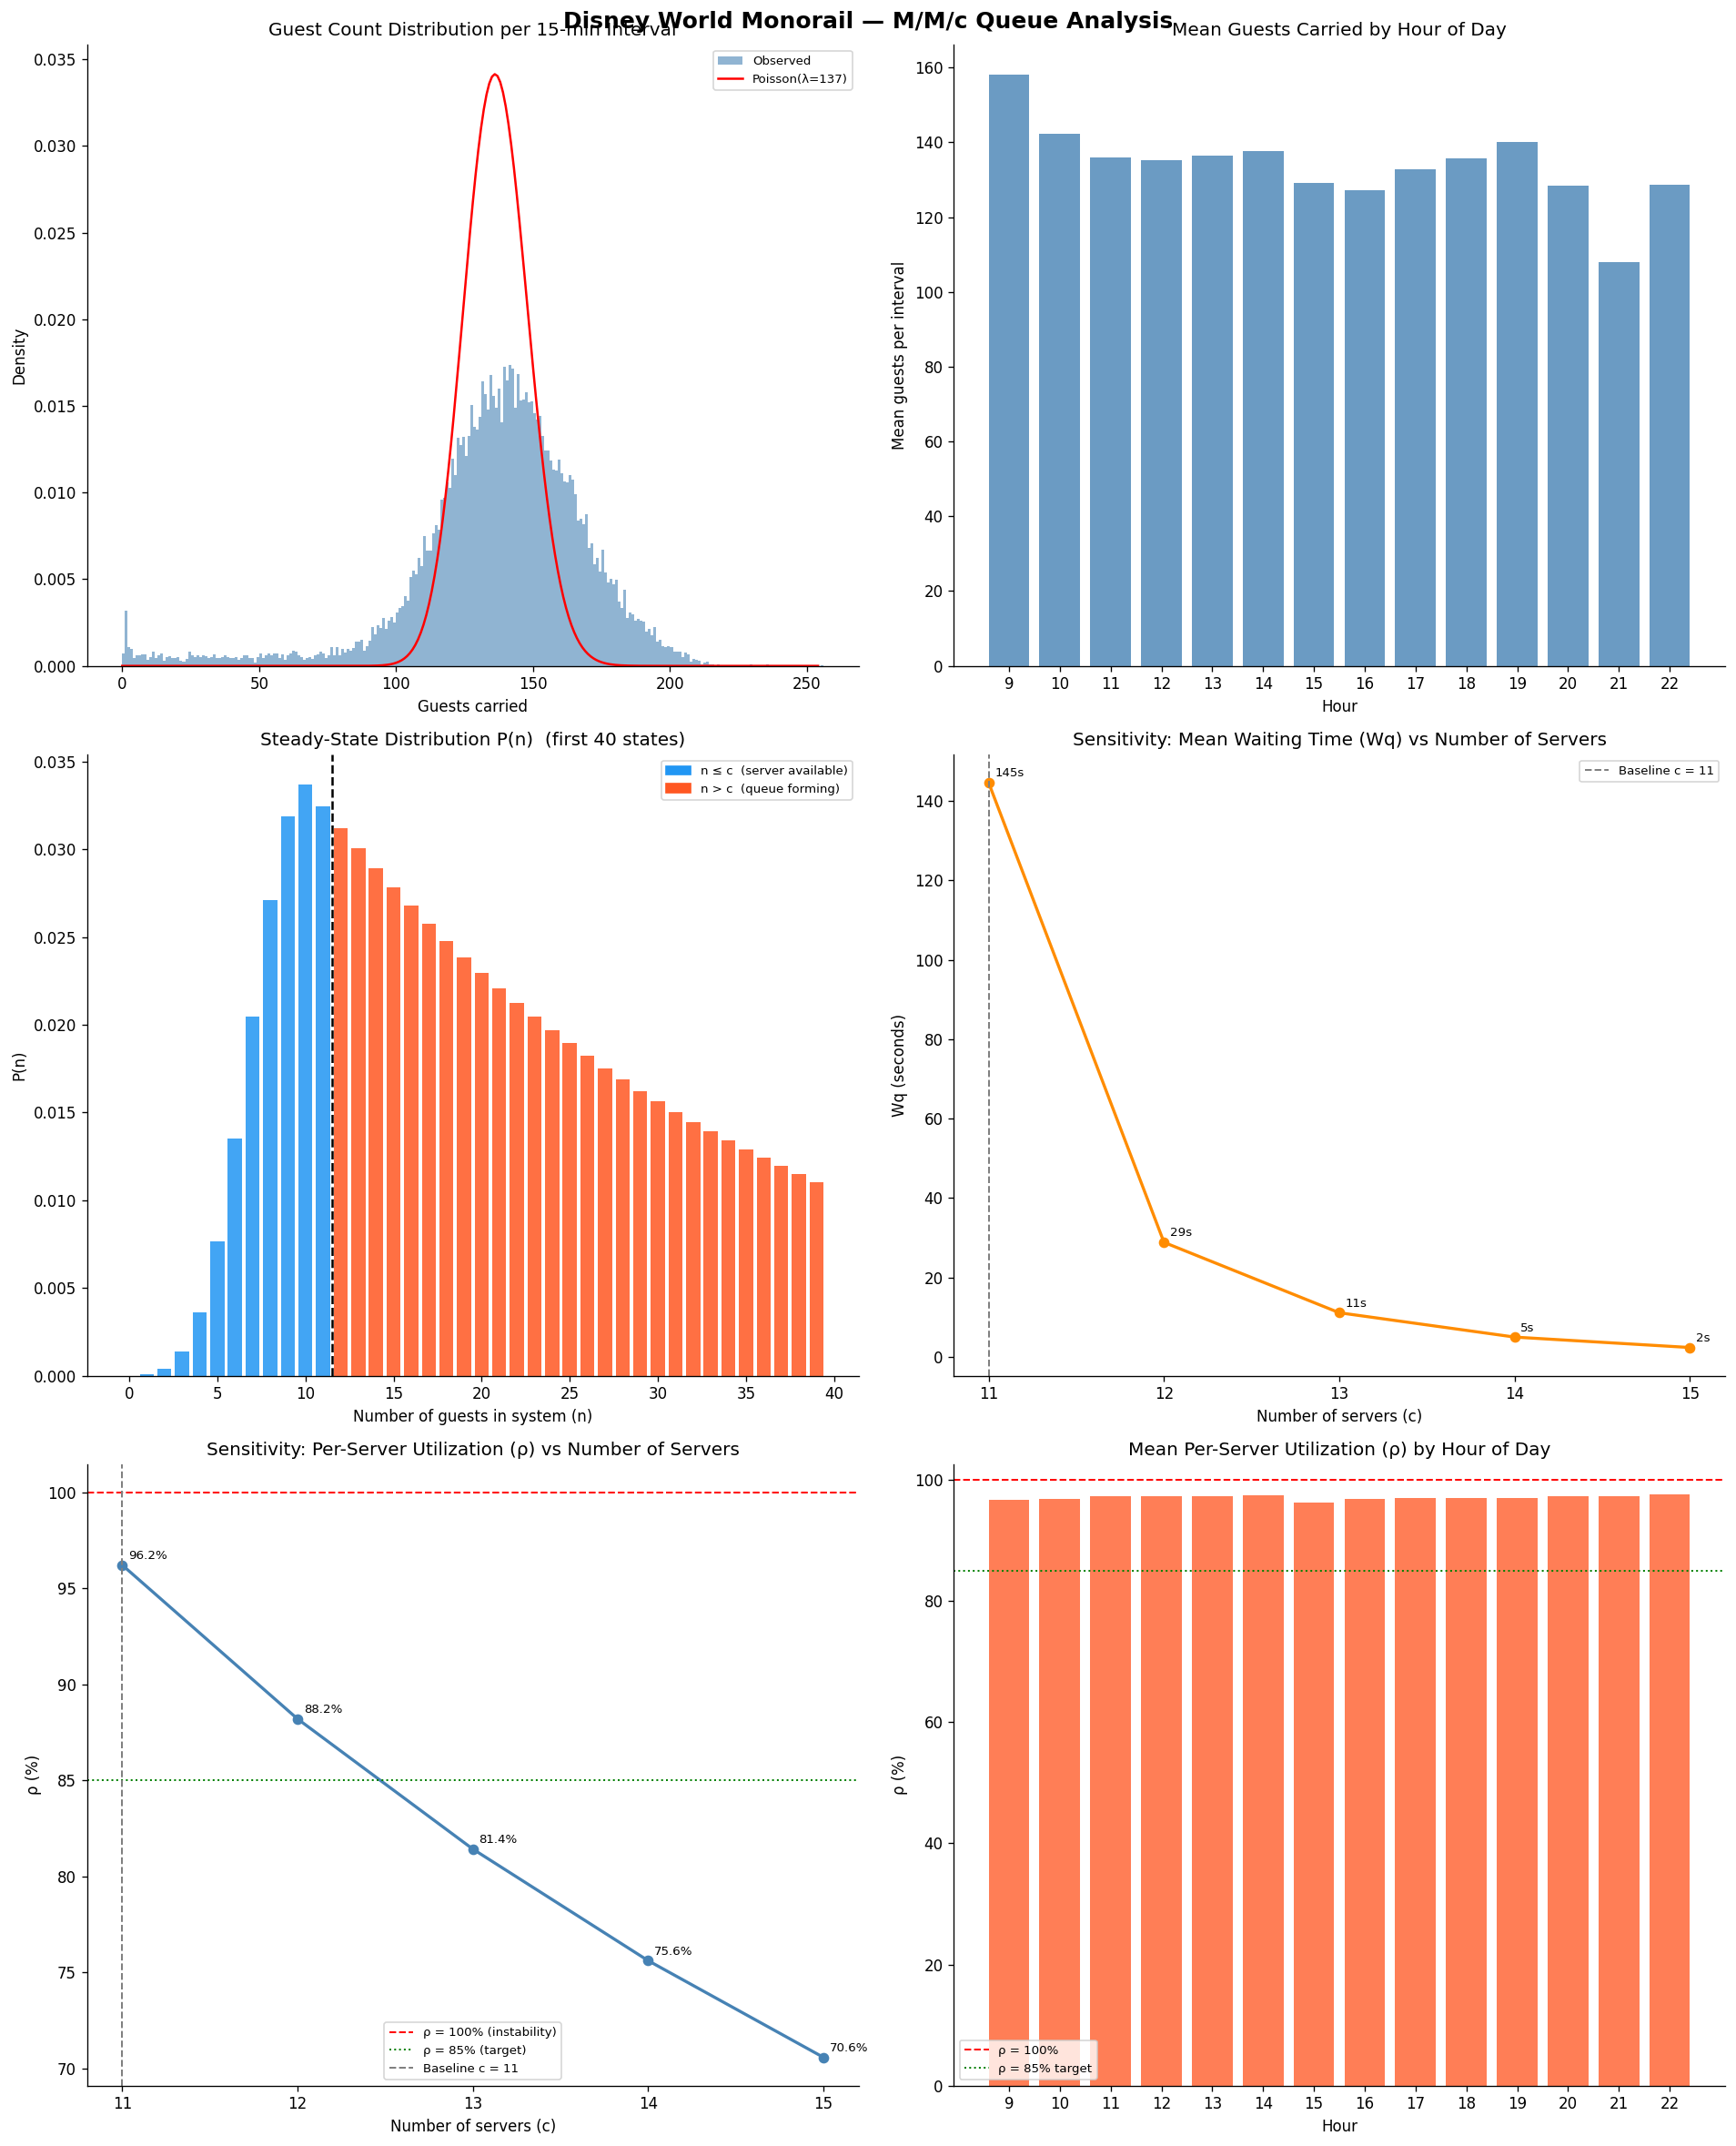

Figure saved: monorail_analysis.png


In [18]:
fig = plt.figure(figsize=(16, 20))
fig.suptitle("Disney World Monorail — M/M/c Queue Analysis",
             fontsize=15, fontweight="bold", y=0.98)

# Guest count distribution vs Poisson
ax1 = fig.add_subplot(3, 2, 1)
counts_plot = mono["GUEST_CARRIED"].astype(int)
bins        = np.arange(counts_plot.min(), counts_plot.max() + 2)
ax1.hist(counts_plot, bins=bins, density=True,
         color="steelblue", alpha=0.6, label="Observed")
x_pois = np.arange(counts_plot.min(), counts_plot.max())
ax1.plot(x_pois,
         stats.poisson.pmf(x_pois, mu=counts_plot.mean()),
         "r-", lw=1.5, label=f"Poisson(λ={counts_plot.mean():.0f})")
ax1.set_title("Guest Count Distribution per 15-min Interval")
ax1.set_xlabel("Guests carried")
ax1.set_ylabel("Density")
ax1.legend(fontsize=8)

# Mean guest count by hour
ax2 = fig.add_subplot(3, 2, 2)
hourly_mean = mono.groupby("DEB_TIME_HOUR")["GUEST_CARRIED"].mean()
ax2.bar(hourly_mean.index, hourly_mean.values, color="steelblue", alpha=0.8)
ax2.set_title("Mean Guests Carried by Hour of Day")
ax2.set_xlabel("Hour")
ax2.set_ylabel("Mean guests per interval")
ax2.set_xticks(hourly_mean.index)

# Steady-state distribution P(n)
ax3 = fig.add_subplot(3, 2, 3)
ns_vis  = list(range(40))
Pns_vis = [compute_Pn(n, lambda_hat, mu_hat, c, P0_val) for n in ns_vis]
colors  = ["#2196F3" if n <= c else "#FF5722" for n in ns_vis]
ax3.bar(ns_vis, Pns_vis, color=colors, alpha=0.85)
ax3.axvline(c + 0.5, color="black", linestyle="--", lw=1.5, label=f"c = {c}")
ax3.set_title("Steady-State Distribution P(n)  (first 40 states)")
ax3.set_xlabel("Number of guests in system (n)")
ax3.set_ylabel("P(n)")
legend_el = [
    mpatches.Patch(color="#2196F3", label="n ≤ c  (server available)"),
    mpatches.Patch(color="#FF5722", label="n > c  (queue forming)"),
]
ax3.legend(handles=legend_el, fontsize=8)

# Sensitivity: Wq vs c
ax4 = fig.add_subplot(3, 2, 4)
df_stable = df_sens[df_sens["status"] != "UNSTABLE"].copy()
ax4.plot(df_stable["c"], df_stable["Wq_sec"], "o-",
         color="darkorange", lw=2, markersize=6)
ax4.axvline(c, color="gray", linestyle="--", lw=1.2, label=f"Baseline c = {c}")
for _, row in df_stable.iterrows():
    ax4.annotate(f"{row['Wq_sec']:.0f}s",
                 xy=(row["c"], row["Wq_sec"]),
                 xytext=(4, 4), textcoords="offset points", fontsize=8)
ax4.set_title("Sensitivity: Mean Waiting Time (Wq) vs Number of Servers")
ax4.set_xlabel("Number of servers (c)")
ax4.set_ylabel("Wq (seconds)")
ax4.set_xticks(df_stable["c"])
ax4.legend(fontsize=8)

# Sensitivity: rho vs c
ax5 = fig.add_subplot(3, 2, 5)
ax5.plot(df_stable["c"], df_stable["rho"] * 100, "o-",
         color="steelblue", lw=2, markersize=6)
ax5.axhline(100, color="red", linestyle="--", lw=1.2, label="ρ = 100% (instability)")
ax5.axhline(85,  color="green", linestyle=":", lw=1.2, label="ρ = 85% (target)")
ax5.axvline(c, color="gray", linestyle="--", lw=1.2, label=f"Baseline c = {c}")
for _, row in df_stable.iterrows():
    ax5.annotate(f"{row['rho']*100:.1f}%",
                 xy=(row["c"], row["rho"] * 100),
                 xytext=(4, 4), textcoords="offset points", fontsize=8)
ax5.set_title("Sensitivity: Per-Server Utilization (ρ) vs Number of Servers")
ax5.set_xlabel("Number of servers (c)")
ax5.set_ylabel("ρ (%)")
ax5.set_xticks(df_stable["c"])
ax5.legend(fontsize=8)

# Hourly rho heatmap
ax6 = fig.add_subplot(3, 2, 6)
hourly_rho = mono.groupby("DEB_TIME_HOUR")["rho_est"].mean()
bar_colors = ["#d32f2f" if r >= 1 else "#ff7043" if r >= 0.95
              else "#ffa726" if r >= 0.85 else "#66bb6a"
              for r in hourly_rho.values]
ax6.bar(hourly_rho.index, hourly_rho.values * 100, color=bar_colors, alpha=0.9)
ax6.axhline(100, color="red",   linestyle="--", lw=1.2, label="ρ = 100%")
ax6.axhline(85,  color="green", linestyle=":",  lw=1.2, label="ρ = 85% target")
ax6.set_title("Mean Per-Server Utilization (ρ) by Hour of Day")
ax6.set_xlabel("Hour")
ax6.set_ylabel("ρ (%)")
ax6.set_xticks(hourly_rho.index)
ax6.legend(fontsize=8)

plt.tight_layout()
plt.savefig("monorail_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: monorail_analysis.png")

## 12. Conclusions & Business Recommendations

### 12.1 Model Summary

This project modeled the Disney World Monorail boarding queue as a **Continuous-Time Markov Chain (CTMC)** under the **M/M/c** framework. Parameters were estimated from 30,108 aggregated 15-minute interval records spanning January 2018 – March 2020.

| Parameter | Value |
|-----------|-------|
| Arrival rate λ | 9.11 guests/min |
| Service rate μ (per server) | 0.86 guests/min |
| Servers c (mode of NB_UNITS) | 11 |
| Per-server utilization ρ | 96.23% |
| Prob. of waiting (Erlang-C) | 86.02% |
| Mean waiting time Wq | 2.41 min (144.6 sec) |
| Mean time in system W | 3.57 min (214.3 sec) |
| Mean queue length Lq | 21.94 guests |

### 12.2 Key Findings

**1. The system operates at near-critical utilization.**  
At ρ = 96.23%, the monorail system has almost no buffer for demand variability. An arriving guest faces an 86% probability of joining a queue before boarding. The steady-state distribution requires 187 states to capture 99.9% of probability mass, reflecting a heavy-tailed queue length distribution consistent with a near-saturated system.

**2. Peak hours push the system into an unstable regime.**  
Hourly analysis reveals that at 09:00 and 10:00, the estimated arrival rate exceeds service capacity (ρ > 1), meaning the system cannot reach steady state during morning peak. This violates the M/M/c stability condition and indicates that the Monorail is genuinely overloaded during these hours — not merely highly utilized.

**3. A single additional server yields an 80% reduction in waiting time.**  
Sensitivity analysis shows that increasing from c = 11 to c = 12 monorail units reduces mean waiting time from 144.6 seconds to 28.8 seconds — an 80.1% improvement. At c = 13, waiting time drops to 11.1 seconds (−92.3%). The marginal benefit diminishes sharply beyond c = 13.

| Servers (c) | ρ | Wq (sec) | Wq reduction |
|-------------|---|----------|-------------|
| 11 (current) | 96.2% | 144.6 | — |
| 12 | 88.2% | 28.8 | −80.1% |
| 13 | 81.4% | 11.1 | −92.3% |
| 14 | 75.6% | 5.0 | −96.6% |
| 15 | 70.6% | 2.4 | −98.4% |

**4. Arrival process exhibits significant overdispersion.**  
The Poisson arrival assumption is formally rejected (VMR = 7.76, χ² = 1,336,114). This is attributable to non-stationary demand — arrival intensity varies systematically by hour (peak at 09:00, trough at 21:00) and likely by season. The M/M/c model is retained as an analytical approximation under local stationarity, which is standard practice in applied queueing analysis.

**5. Posted wait times (WAIT_TIME_MAX) reflect operational decisions, not queue dynamics.**  
The observed mean of WAIT_TIME_MAX (61.5 minutes) is an order of magnitude larger than the theoretical Wq (2.41 minutes). This gap is expected: WAIT_TIME_MAX is the publicly posted board time — a strategic communication tool influenced by crowd management policy — rather than the actual per-guest waiting time modeled by Wq. Near-zero correlation between ρ̂ and WAIT_TIME_MAX (r = 0.02) confirms that posted times are not driven by the instantaneous queue state captured in this model.

### 12.3 Recommendations

**Operational (short-term)**  
- Deploy a minimum of **c = 12 units** during standard operating hours to reduce ρ below 90% and cut mean waiting time by 80%.  
- During morning peak (09:00–10:00), where ρ > 1 under current capacity, deploy at least **c = 13 units** to restore system stability. The hourly breakdown shows these two hours alone consistently drive the system into a non-steady-state regime.

**Scheduling (medium-term)**  
- Implement **time-varying capacity**: c = 13 from 09:00–11:00, stepping down to c = 12 from 11:00–19:00, and c = 11 for evening hours (20:00 onward) where demand is lower and rho naturally falls below 90%. This avoids the cost of maintaining maximum capacity throughout the day.

**Data collection (long-term)**  
- The absence of individual arrival timestamps limits model precision. Collecting **per-guest boarding timestamps** would enable direct MLE of λ from inter-arrival times, proper exponentiality testing, and a more rigorous CTMC fit. This would also allow direct comparison of Wq against actual (rather than posted) wait times.

### 12.4 Model Limitations

- **Aggregated data:** λ and μ are estimated from 15-minute interval totals, not individual event times. This introduces estimation error and prevents direct validation of the exponential inter-arrival assumption at the event level.
- **Stationarity assumption:** M/M/c assumes time-homogeneous rates. The observed hourly and seasonal variation violates this; results represent a long-run average rather than instantaneous behavior.
- **Infinite queue capacity:** The model assumes unbounded queue length. In practice, physical space and guest abandonment impose a finite limit, suggesting an M/M/c/K or M/M/c/K/K model may be more appropriate.
- **Homogeneous servers:** All c monorail units are assumed identical. Differences in train capacity or dwell time are not captured.